In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.2 MB/s eta 0:00:00


# Paste your Roboflow code under this cell

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gL9gSMJRQ9mmVYNytssf")
project = rf.workspace("infocomm-roboflow").project("distracted-driving-v2wk5-qdrrf")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 80.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Distracted-Driving-2 in yolov8:: 100%|██████████| 44929/44929 [00:06<00:00, 6892.99it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import os
import glob

for split in ['train', 'valid', 'test']:
    label_dir = f"{dataset.location}/{split}/labels"
    for label_file in glob.glob(f"{label_dir}/*.txt"):
        with open(label_file, 'r') as f:
            lines = f.readlines()

        classes = [int(line.strip().split()[0]) for line in lines if line.strip()]

        if 0 in classes and 1 in classes:
            lines = [line for line in lines if not line.strip().startswith('0 ')]

        with open(label_file, 'w') as f:
            f.writelines(lines)

print("fixed conflicting labels")


fixed conflicting labels


In [1]:
from ultralytics import YOLO

def freeze_layer(trainer):
    model = trainer.model
    num_freeze = 22
    print(f"Freezing {num_freeze} layers")
    freeze = [f'model.{x}.' for x in range(num_freeze)]  # layers to freeze
    for k, v in model.named_parameters():
        v.requires_grad = True  # train all layers
        if any(x in k for x in freeze):
            print(f'freezing {k}')
            v.requires_grad = False
    print(f"{num_freeze} layers are freezed.")
if __name__ == '__main__':
  model = YOLO('yolov8s.pt')
  model.train(
    data=f"/content/Distracted-Driving-2/data.yaml",
    epochs=67,
    batch=32,
    imgsz=640,
    freeze=0,
    optimizer='AdamW',
    lr0=0.0005,
    patience=15,
    cos_lr=True,
    cache=True,
    workers=4,
    name='MODEL'
)




Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Distracted-Driving-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=67, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=MODEL-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pat

KeyboardInterrupt: 

In [5]:
model = YOLO('/content/runs/detect/MODEL-4/weights/best.pt')

In [6]:
im = model.predict('/content/Distracted-Driving-2/test/images', save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1005 /content/Distracted-Driving-2/test/images/0B5B4A0B-E106-46FE-906A-B5BA65A853CD_jpeg.rf.43a5ad2de053ea6a14c6f9379e00ed4b.jpg: 640x640 2 distracteds, 16.2ms
image 2/1005 /content/Distracted-Driving-2/test/images/0F1A934A-8C62-4419-897E-4EE9581B9280_jpeg.rf.fe2ea967b320b246b234db68e2543323.jpg: 640x640 2 distracteds, 16.3ms
image 3/1005 /content/Distracted-Driving-2/test/images/18EBD33C-2624-4A40-B831-FD8477225521_jpeg.rf.35e23c82adfc32aaaff91d

['729F1A86-069F-4E61-82D1-20796D72875A_jpeg.rf.e9b99d3bb33c9b4a7119fff29346b603.jpg', 'img_2765_jpg.rf.e3243cc1227dc28706997296bee137cf.jpg', 'img_4733_jpg.rf.01e2fecdad1ca2f68c842ec301abe1fd.jpg', 'img_4960_jpg.rf.e3a48dc78544568a8a8b99ed0e30c3e0.jpg', 'img_41596_jpg.rf.0a1c0bc5b55958bd927b3daf5a73f2fc.jpg', 'img_337_jpg.rf.802b1d2e4317fd7c29762d942de97387.jpg', 'img_14313_jpg.rf.686bec7632d042a118f0f909197d1705.jpg', 'img_3478_jpg.rf.d8937d5ad9f07f6c75326c2273cbfcb4.jpg', 'img_35073_jpg.rf.b3072bc632ee3fc4a72d2915345f7cd3.jpg', 'img_45923_jpg.rf.a7cbbfe2fa65b90f256c0a2382d6f560.jpg', 'img_39101_jpg.rf.aa1d764cad1a389a2f92a10a8188c816.jpg', 'img_4629_jpg.rf.cc10b9c86e9f61317e6be098cc23dc8d.jpg', 'img_23004_jpg.rf.8108e93b9b84378cf5af77da73f7a070.jpg', 'img_16033_jpg.rf.efaa048e3eee86d2ef6f482127b1bc62.jpg', 'img_32631_jpg.rf.c8dd2f416b7ba2e831f9dd23e16e9e37.jpg', 'img_9098_jpg.rf.44612f36d36f9290e946c215db7fddf5.jpg', 'img_41136_jpg.rf.b7c254af4317363dea327fd950c510e3.jpg', 'img_1942_

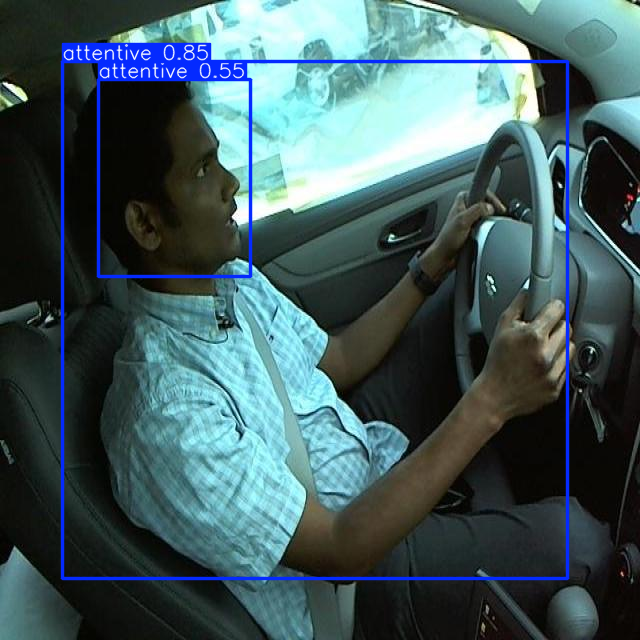

In [7]:
PATH="/content/runs/detect/predict"
from google.colab.patches import cv2_imshow
import cv2
import os
test_images = os.listdir("/content/Distracted-Driving-2/test/images")
print(test_images[10:])  # show first 10 filenames
results = model.predict('/content/Distracted-Driving-2/test/images/img_35073_jpg.rf.b3072bc632ee3fc4a72d2915345f7cd3.jpg', save=True)
im = results[0].plot() # Get the annotated image (NumPy array) from the first Results object

cv2_imshow(im)

['img_18225_jpg.rf.490274453872b9430f14e4daa396c4d0.jpg', 'img_6620_jpg.rf.1734cfa89d44e86046cb2b4500edd10d.jpg', 'img_18138_jpg.rf.e16bf8713a5407121576fec5ee1b3955.jpg', 'img_9150_jpg.rf.17e940bfd18b3d214e6ff3d84d6e851e.jpg', '4B050AB4-BC43-4F56-A742-2693CA825DA7_jpeg.rf.95eaba16bd6c9246187e2ac75310d2e9.jpg', 'Image_20220611200842_jpg.rf.fec2887c87bfc95a28806e82fb42a560.jpg', 'img_15321_jpg.rf.c4891dec14410d64d57ac7cd36e03f66.jpg', 'Image_20220611200857_052_jpg.rf.1216a3eb7ec653a35bc363051149ccd9.jpg', 'img_19780_jpg.rf.82f4abf761ea161cac175ac00634aab2.jpg', 'img_38944_jpg.rf.cce2fd329c5216d60f23756c093c189a.jpg']

image 1/1 /content/Distracted-Driving-2/test/images/4B050AB4-BC43-4F56-A742-2693CA825DA7_jpeg.rf.95eaba16bd6c9246187e2ac75310d2e9.jpg: 640x640 1 distracted, 42.9ms
Speed: 6.4ms preprocess, 42.9ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


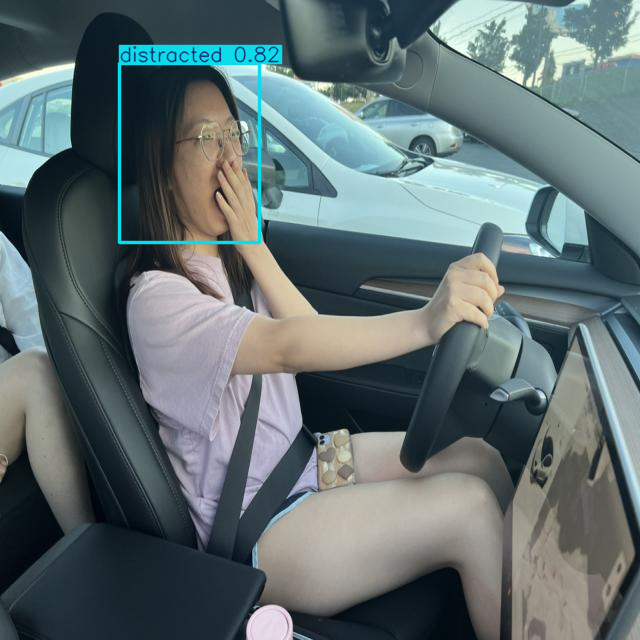

In [46]:
PATH="/content/runs/detect/predict"
from google.colab.patches import cv2_imshow
import cv2
import os
test_images = os.listdir("/content/Distracted-Driving-2/test/images")
print(test_images[-10:])  # show first 10 filenames
results = model.predict('/content/Distracted-Driving-2/test/images/4B050AB4-BC43-4F56-A742-2693CA825DA7_jpeg.rf.95eaba16bd6c9246187e2ac75310d2e9.jpg', save=True)
im = results[0].plot() # Get the annotated image (NumPy array) from the first Results object

cv2_imshow(im)